# Finite State Machines

A **finite state machine** (FSM), or **finite automaton**, is one of the simplest models of computation. It has a finite number of **states** and reads an input string one symbol at a time, changing state according to a fixed rule. FSMs power things like text-pattern matchers, network protocols, vending machines, and the lexical analyzers in compilers.

In this notebook we focus on the **deterministic finite automaton (DFA)**, build a simulator for it, and draw its **state diagram**. FSMs are the machines that recognize exactly the **regular languages** of notebook 14.

## Formal Definition (DFA)

A **deterministic finite automaton** is a 5-tuple $(Q, \Sigma, \delta, q_0, F)$:

- $Q$ — a finite set of **states**,
- $\Sigma$ — a finite **alphabet** of input symbols,
- $\delta : Q \times \Sigma \to Q$ — the **transition function** (from a state and a symbol, exactly one next state),
- $q_0 \in Q$ — the **start state**,
- $F \subseteq Q$ — the set of **accepting** (final) states.

The machine starts in $q_0$, reads the input symbol by symbol following $\delta$, and **accepts** the string if it ends in a state belonging to $F$. We can store $\delta$ as a Python dictionary keyed by `(state, symbol)`.

In [1]:
# DFA #1: accept binary strings with an EVEN number of 1s.
even_ones = {
    "states": {"even", "odd"},
    "alphabet": {"0", "1"},
    "transitions": {
        ("even", "0"): "even", ("even", "1"): "odd",
        ("odd", "0"): "odd",  ("odd", "1"): "even",
    },
    "start": "even",
    "accept": {"even"},
}


def run_dfa(dfa, string):
    state = dfa["start"]
    for ch in string:
        state = dfa["transitions"][(state, ch)]
    return state in dfa["accept"]


for s in ["", "11", "1", "101", "1011", "111000"]:
    ones = s.count("1")
    print(f"{s or '(empty)':>8}:  accepted={run_dfa(even_ones, s)!s:<5}  (#1s = {ones}, even? {ones % 2 == 0})")

 (empty):  accepted=True   (#1s = 0, even? True)
      11:  accepted=True   (#1s = 2, even? True)
       1:  accepted=False  (#1s = 1, even? False)
     101:  accepted=True   (#1s = 2, even? True)
    1011:  accepted=False  (#1s = 3, even? False)
  111000:  accepted=False  (#1s = 3, even? False)


## State Diagrams

An FSM is usually drawn as a **state diagram**: a node per state, and a labeled arrow $q \xrightarrow{a} q'$ for each transition $\delta(q, a) = q'$. The start state has an incoming arrow from nowhere, and accepting states are drawn with a double circle (here we color them green).

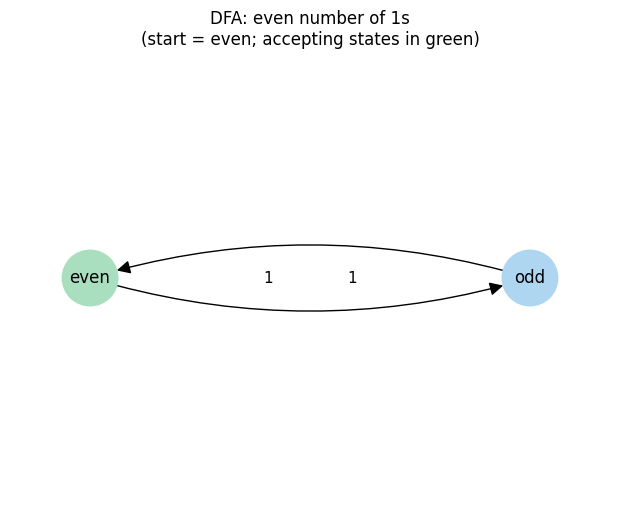

In [2]:
import networkx as nx
import matplotlib.pyplot as plt


def draw_dfa(dfa, title, seed=1):
    # Combine all symbols that go between the same pair of states onto one label.
    edge_syms = {}
    for (s, sym), t in dfa["transitions"].items():
        edge_syms.setdefault((s, t), []).append(sym)

    G = nx.DiGraph()
    G.add_nodes_from(dfa["states"])
    for (s, t), syms in edge_syms.items():
        G.add_edge(s, t, label=",".join(sorted(syms)))

    pos = nx.circular_layout(G)
    colors = ["#a9dfbf" if s in dfa["accept"] else "#aed6f1" for s in G.nodes()]
    plt.figure(figsize=(6, 4.5))
    nx.draw(G, pos, with_labels=True, node_color=colors, node_size=1600, font_size=12,
            arrowsize=20, connectionstyle="arc3,rad=0.15")
    nx.draw_networkx_edge_labels(
        G, pos, edge_labels={(s, t): d["label"] for s, t, d in G.edges(data=True)},
        font_size=11, label_pos=0.4)
    plt.title(f"{title}\n(start = {dfa['start']}; accepting states in green)")
    plt.margins(0.12)
    plt.show()


draw_dfa(even_ones, "DFA: even number of 1s")

## A Second Example: Divisibility by 3

FSMs can do real arithmetic with only a handful of states. Reading a binary number from most-significant bit to least-significant, the value-so-far satisfies

$$\text{new remainder} = (2 \cdot \text{old remainder} + \text{bit}) \bmod 3.$$

So three states — one per remainder $\{0, 1, 2\}$ — are enough to test whether a binary string represents a multiple of $3$. The accepting state is remainder $0$.

     0 =   0:  accepted=True   (divisible by 3? True)
    11 =   3:  accepted=True   (divisible by 3? True)
   110 =   6:  accepted=True   (divisible by 3? True)
    10 =   2:  accepted=False  (divisible by 3? False)
  1001 =   9:  accepted=True   (divisible by 3? True)
  1111 =  15:  accepted=True   (divisible by 3? True)


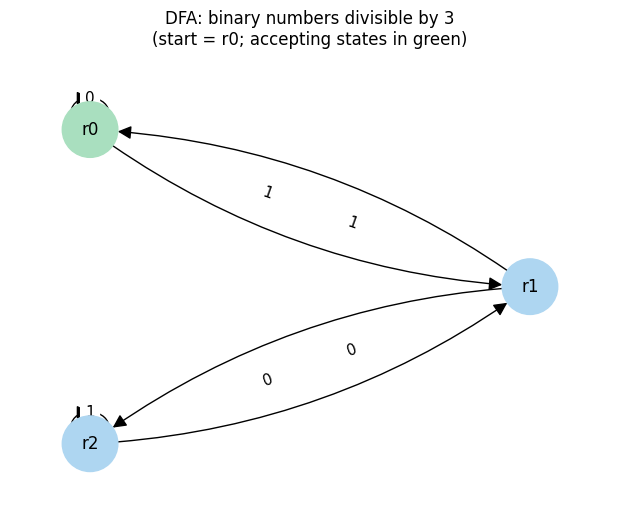

In [3]:
div3 = {
    "states": {"r0", "r1", "r2"},
    "alphabet": {"0", "1"},
    "transitions": {
        ("r0", "0"): "r0", ("r0", "1"): "r1",
        ("r1", "0"): "r2", ("r1", "1"): "r0",
        ("r2", "0"): "r1", ("r2", "1"): "r2",
    },
    "start": "r0",
    "accept": {"r0"},
}

for s in ["0", "11", "110", "10", "1001", "1111"]:
    value = int(s, 2)
    print(f"{s:>6} = {value:>3}:  accepted={run_dfa(div3, s)!s:<5}  (divisible by 3? {value % 3 == 0})")

draw_dfa(div3, "DFA: binary numbers divisible by 3")

## DFA vs. NFA

In a **nondeterministic finite automaton (NFA)** a state may have several (or zero) transitions on the same symbol, and the machine accepts if *any* path of choices reaches an accepting state. NFAs are often easier to design, but they are **no more powerful** than DFAs: every NFA can be converted to an equivalent DFA (the *subset construction*). Both recognize exactly the regular languages.

## Machines with Output: Mealy Machines

The DFAs above only answer yes/no (accept/reject). A **Mealy machine** instead produces an **output symbol on each transition**, so it transforms an input string into an output string. (A closely related **Moore machine** attaches the output to the *state* instead of the transition.)

The machine below reads bits and outputs `1` exactly when it has just completed the substring `"11"` (the current bit and the previous bit are both `1`), and `0` otherwise.

In [4]:
def run_mealy_detect_11(bits):
    state = "prev0"     # whether the previous bit was a 1
    output = ""
    for ch in bits:
        if state == "prev0":
            output += "0"
            state = "prev1" if ch == "1" else "prev0"
        else:  # state == "prev1"
            if ch == "1":
                output += "1"      # just saw "11"
                state = "prev1"
            else:
                output += "0"
                state = "prev0"
    return output


inp = "0110110"
print("input :", inp)
print("output:", run_mealy_detect_11(inp), " (a 1 marks the end of each '11')")

input : 0110110
output: 0010010  (a 1 marks the end of each '11')


## Worked Examples

A few examples solved with Python. (The exercises in the next section are for you to solve — their solutions live in the matching notebook in `solutions/`.)

### Example 1: A DFA That Accepts Strings Containing 'ab'

Design a DFA over $\{a, b\}$ that accepts exactly the strings containing the substring `ab`, and test it.

In [5]:
delta = {
    ("q0", "a"): "q1", ("q0", "b"): "q0",
    ("q1", "a"): "q1", ("q1", "b"): "q2",
    ("q2", "a"): "q2", ("q2", "b"): "q2",
}

def run(s):
    state = "q0"
    for ch in s:
        state = delta[(state, ch)]
    return state == "q2"

for s in ["ab", "aab", "ba", "bbb", "aabb"]:
    print(f"{s:>5}: contains 'ab'? {run(s)}")

   ab: contains 'ab'? True
  aab: contains 'ab'? True
   ba: contains 'ab'? False
  bbb: contains 'ab'? False
 aabb: contains 'ab'? True


### Example 2: A DFA for Even-Length Strings

Only two states are needed to track whether the number of symbols read so far is even or odd.

In [6]:
def even_length(s):
    state = "even"
    for _ in s:
        state = "odd" if state == "even" else "even"
    return state == "even"

for s in ["", "ab", "a", "abab", "aba"]:
    print(f"{s or '(empty)':>8}: even length? {even_length(s)}")

 (empty): even length? True
      ab: even length? True
       a: even length? False
    abab: even length? True
     aba: even length? False


## Finite State Machines Practice Problems

Write your Python in the code cell beneath each problem (some starter code is provided). Worked solutions are in [`solutions/13_finite_state_machines_key.ipynb`](solutions/13_finite_state_machines_key.ipynb).

### Problem 1: Run a DFA

The DFA in the starter (over $\{a, b\}$) accepts strings that **end in `a`**. Write a `run` function that returns whether each test string is accepted.

In [ ]:
delta = {("not_a", "a"): "saw_a", ("not_a", "b"): "not_a",
         ("saw_a", "a"): "saw_a", ("saw_a", "b"): "not_a"}
start, accept = "not_a", {"saw_a"}
tests = ["a", "b", "ba", "ab", "bba"]
# WRITE YOUR CODE BELOW


### Problem 2: Even Number of 1s

Write a DFA simulation that accepts binary strings with an **even** number of 1s, and test it on several strings.

In [ ]:
tests = ["", "11", "1", "101", "1011"]
# WRITE YOUR CODE BELOW


### Problem 3: Divisible by 3

Reading a binary string most-significant-bit first, the running remainder updates as $r \leftarrow (2r + \text{bit}) \bmod 3$. Use this to test whether each binary string represents a multiple of 3.

In [ ]:
tests = ["11", "110", "10", "1001"]
# WRITE YOUR CODE BELOW


### Problem 4: A Mealy Machine

Write a Mealy machine that reads bits and outputs `1` exactly when it has just completed the substring `11` (the current bit and the previous bit are both 1), and `0` otherwise. Run it on `0110110`.

In [ ]:
bits = "0110110"
# WRITE YOUR CODE BELOW
